In [3]:
import pandas as pd
import os

# Path to raw data
data_path = "../data/raw"

# List all CSV files
files = os.listdir(data_path)

print("Files found:", files)
print("\n" + "="*50 + "\n")


for file in files:
    if file.endswith(".csv"):
        print(f"📊 Processing file: {file}")
        
        file_path = os.path.join(data_path, file)
        df = pd.read_csv(file_path)
        
        print("\n🔹 Top 5 rows:")
        print(df.head())
        
        print("\n🔹 Shape (rows, columns):")
        print(df.shape)
        
        print("\n🔹 Columns:")
        print(df.columns.tolist())
        
        print("\n🔹 Missing values:")
        print(df.isnull().sum())
        
        print("\n" + "="*50 + "\n")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

Files found: ['NSEBANK.csv', 'NSEI.csv', 'SBIN.NS.csv']


📊 Processing file: NSEBANK.csv

🔹 Top 5 rows:
         Date          Open          High           Low         Close     Adj Close  Volume    Ticker
0  2021-03-22  34088.398438  34148.898438  33389.148438  33603.449219  33603.058594       0  ^NSEBANK
1  2021-03-23  33747.949219  34360.050781  33622.000000  34184.398438  34184.000000       0  ^NSEBANK
2  2021-03-24  33894.699219  33970.648438  33203.398438  33293.250000  33292.863281       0  ^NSEBANK
3  2021-03-25  33420.750000  33550.148438  32415.250000  33006.449219  33006.066406       0  ^NSEBANK
4  2021-03-26  33605.050781  33610.648438  33166.101562  33318.199219  33317.812500       0  ^NSEBANK

🔹 Shape (rows, columns):
(1235, 8)

🔹 Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Ticker']

🔹 Missing values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Ticker       0
dtype: int64


📊 Proces

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
sbi = pd.read_csv("../data/raw/SBIN.NS.csv")
nifty = pd.read_csv("../data/raw/NSEI.csv")
banknifty = pd.read_csv("../data/raw/NSEBANK.csv")

for df in [sbi, nifty, banknifty]:
    df["Date"] = pd.to_datetime(df["Date"])

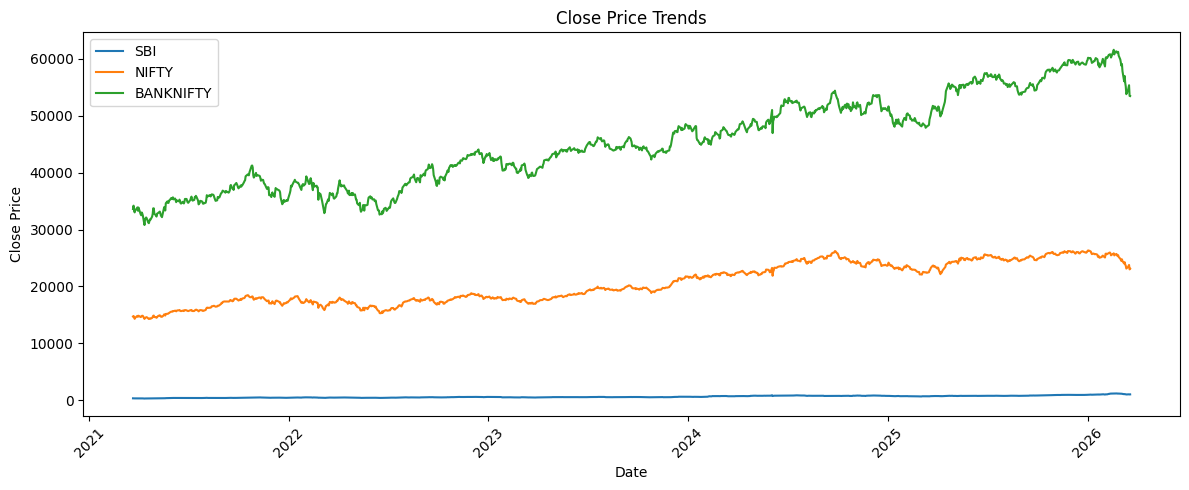

In [3]:
plt.figure()
plt.plot(sbi["Date"], sbi["Close"], label="SBI")
plt.plot(nifty["Date"], nifty["Close"], label="NIFTY")
plt.plot(banknifty["Date"], banknifty["Close"], label="BANKNIFTY")
plt.title("Close Price Trends")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

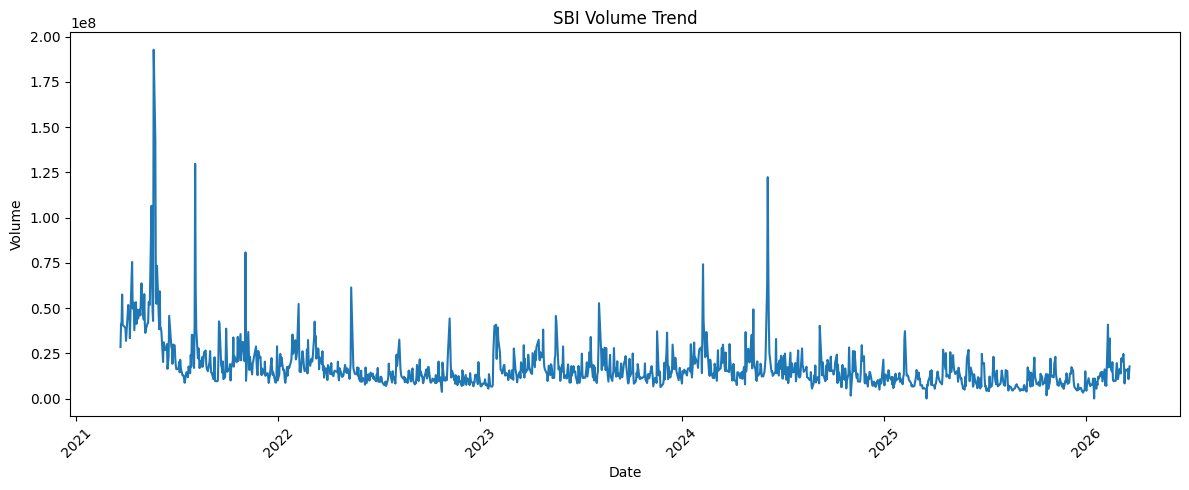

In [4]:
plt.figure()
plt.plot(sbi["Date"], sbi["Volume"])
plt.title("SBI Volume Trend")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

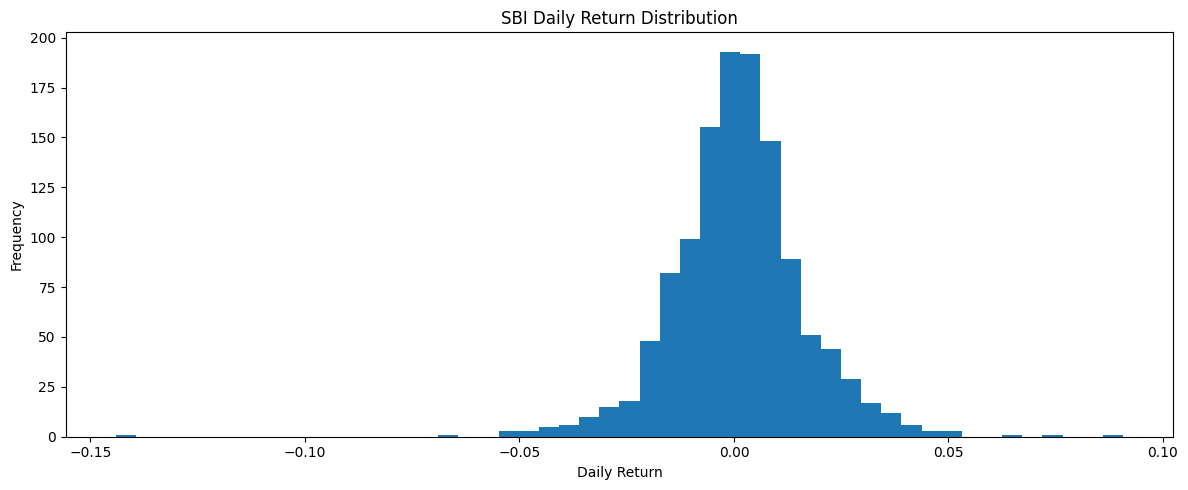

In [5]:
sbi["return_1d"] = sbi["Close"].pct_change()

plt.figure()
plt.hist(sbi["return_1d"].dropna(), bins=50)
plt.title("SBI Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

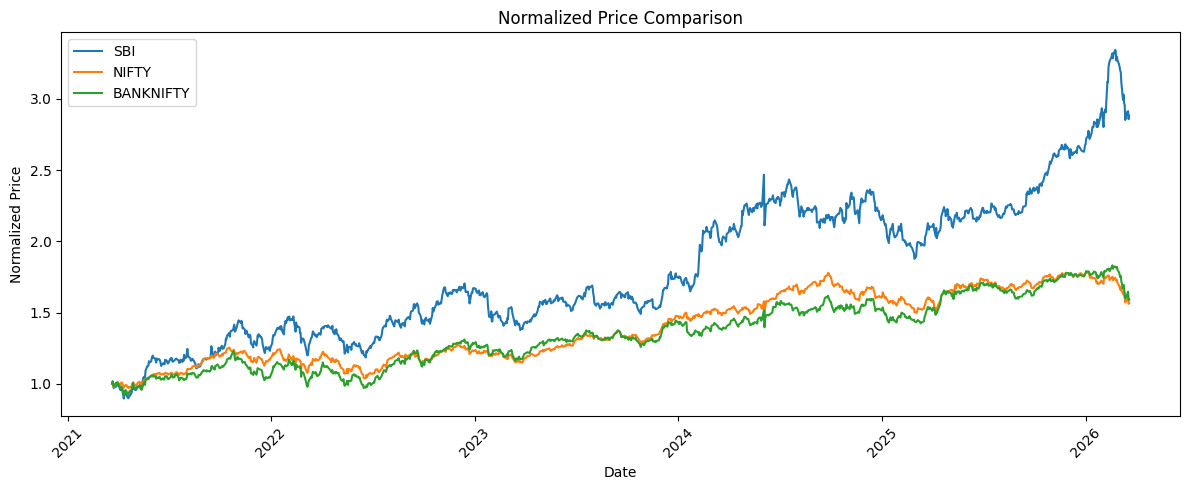

In [6]:
sbi_norm = sbi["Close"] / sbi["Close"].iloc[0]
nifty_norm = nifty["Close"] / nifty["Close"].iloc[0]
banknifty_norm = banknifty["Close"] / banknifty["Close"].iloc[0]

plt.figure()
plt.plot(sbi["Date"], sbi_norm, label="SBI")
plt.plot(nifty["Date"], nifty_norm, label="NIFTY")
plt.plot(banknifty["Date"], banknifty_norm, label="BANKNIFTY")
plt.title("Normalized Price Comparison")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()